In [43]:
# Importa la biblioteca para operaciones matemáticas
import numpy as np
# Importa la biblioteca para crear gráficas
import matplotlib.pyplot as plt
# Importa la biblioteca matemática
import math

In [44]:
# Define la función de Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define una red neuronal superficial
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Asegura que los datos de entrada sean un arreglo de tamaño (1 x n_data)
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # Ejecuta la red para TODAS las entradas x a la vez para poder dibujar la gráfica
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    y = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return y

In [45]:
# Obtiene los parámetros del modelo; podemos llamar esta función para reiniciarlos fácilmente
def get_parameters():
  # Crea una red que se ajusta aproximadamente a los datos
  beta_0 = np.zeros((3,1));  # anteriormente theta_x0
  omega_0 = np.zeros((3,1)); # anteriormente theta_x1
  beta_1 = np.zeros((1,1));  # anteriormente phi_0
  omega_1 = np.zeros((1,3)); # anteriormente phi_x

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 0.1;
  omega_1[0,0] = -2.0; omega_1[0,1] = -1.0; omega_1[0,2] = 7.0

  return beta_0, omega_0, beta_1, omega_1

In [46]:
# Función auxiliar para graficar los datos
def plot_univariate_regression(x_model, y_model, x_data = None, y_data = None, sigma_model = None, title= None):
  # Asegura que los datos del modelo sean arreglos unidimensionales
  x_model = np.squeeze(x_model)
  y_model = np.squeeze(y_model)

  fig, ax = plt.subplots()
  ax.plot(x_model,y_model)
  if sigma_model is not None:
    ax.fill_between(x_model, y_model-2*sigma_model, y_model+2*sigma_model, color='lightgray')
  ax.set_xlabel(r'Entrada, $x$'); ax.set_ylabel(r'Salida, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if title is not None:
    ax.set_title(title)
  if x_data is not None:
    ax.plot(x_data, y_data, 'ko')
  plt.show()

# Regresión univariada

Estudiaremos una situación sencilla de regresión univariada con una sola entrada $x$ y una sola salida $y$

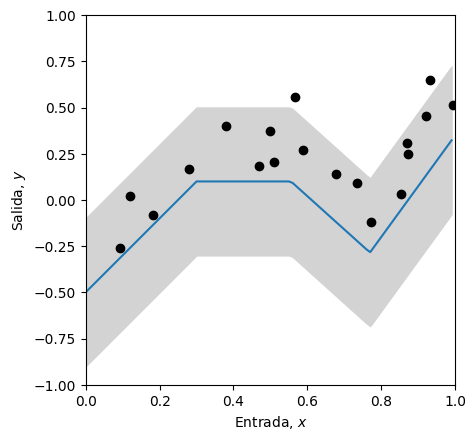

In [47]:
# Crea algunos datos de entrenamiento unidimensionales
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.25934537,0.18195445,0.651270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.20716968,-0.08131792,0.51187806,0.16943738,0.3994327,\
                    0.019062570,0.55820410,0.452564960,-0.1183121,0.02957665,-1.24354444, \
                    0.248038840,0.26824970])

# Obtiene los parámetros del modelo
beta_0, omega_0, beta_1, omega_1 = get_parameters()
sigma = 0.2

# Define un intervalo de valores de entrada
x_model = np.arange(0,1,0.01)
# Ejecuta el modelo para obtener los valores y graficarlos
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma)


La línea azul es la predicción media del modelo y el área gris representa más/menos dos desviaciones estándar. Este modelo se ajusta razonablemente, pero podría mejorar. Calculemos la pérdida mediante el error de mínimos cuadrados, la likelihood y la log-likelihood negativa.

In [48]:
# Devuelve la probabilidad bajo una distribución normal
import math
def normal_distribution(y, mu, sigma):
    # TODO: escribe la ecuación de la distribución normal
    # Ecuación 5.7 de las notas (necesitarás np.sqrt(), np.exp() y math.pi)
    # No uses la versión de NumPy; eso sería hacer trampa.
    # Reemplaza la siguiente línea

    prob = (1 / np.sqrt(2 * math.pi * sigma**2)) * \
           np.exp(-((y - mu)**2) / (2 * sigma**2))

    return prob

En esta sección se implementó la función normal_distribution(), utilizando la ecuación 5.7 correspondiente a la función de densidad de probabilidad de una distribución normal (Gaussiana). La función recibe como parámetros los datos de entrada (y), la media (μ) y la desviación estándar (σ), y devuelve la probabilidad asociada a cada observación. Esta implementación constituye la base para calcular posteriormente la Likelihood y la Negative Log-Likelihood, funciones empleadas durante el proceso de optimización del modelo.


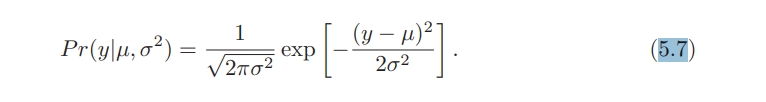


In [49]:
# Verifica que obtengamos la respuesta correcta antes de continuar
print("Respuesta correcta = %3.3f, Tu respuesta = %3.3f"%(0.119,normal_distribution(1,-1,2.3)))

Respuesta correcta = 0.119, Tu respuesta = 0.119


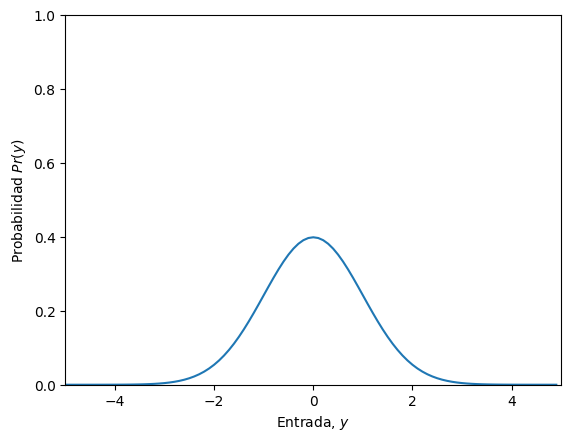

In [50]:
# Grafica la distribución gaussiana
y_gauss = np.arange(-5,5,0.1)
mu = 0; sigma = 1.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel(r'Entrada, $y$'); ax.set_ylabel(r'Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

# TODO
# 1. Predice qué ocurrirá si cambiamos a mu=1 y dejamos sigma=1
# Ahora cambia el código anterior y comprueba si tu predicción fue correcta.

# 2. Predice qué ocurrirá si dejamos mu=0 y cambiamos sigma a 2.0

# 3. Predice qué ocurrirá si dejamos mu=0 y cambiamos sigma a 0.5

###1. Predice qué ocurrirá si cambiamos a mu=1 y dejamos sigma=1

Al cambiar μ=1 y mantener σ=1, la distribución se desplazará una unidad hacia la derecha sin modificar su forma. El ancho y la altura máxima permanecerán prácticamente iguales, ya que únicamente cambia la posición del centro de la distribución.

###Ahora cambia el código anterior y comprueba si tu predicción fue correcta.

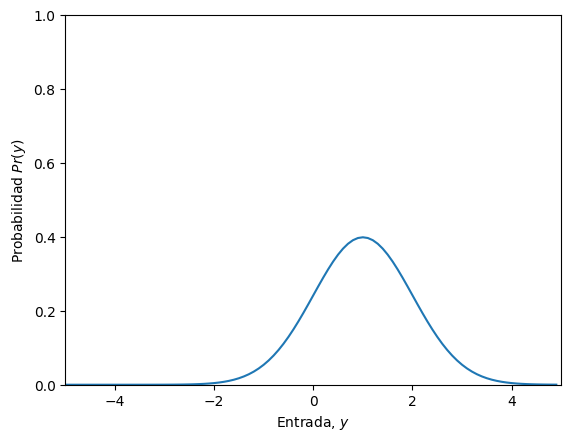

In [51]:
# Grafica la distribución gaussiana
y_gauss = np.arange(-5,5,0.1)
mu = 1; sigma = 1.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel(r'Entrada, $y$'); ax.set_ylabel(r'Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

###2. Predice qué ocurrirá si dejamos mu=0 y cambiamos sigma a 2.0
Al mantener μ=0 y aumentar σ a 2.0, la distribución será más ancha y su altura máxima disminuirá. Esto ocurre porque una desviación estándar mayor indica que los datos presentan una mayor dispersión alrededor de la media.

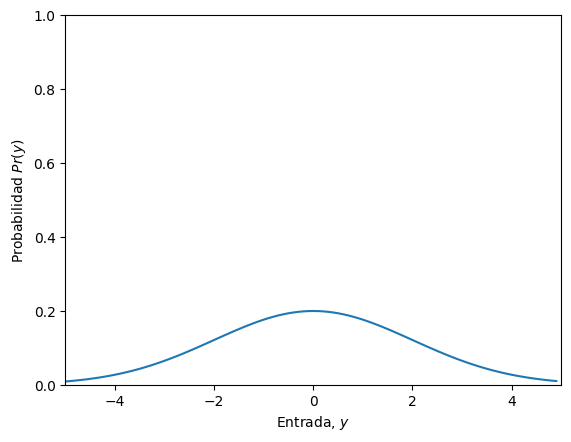

In [52]:
y_gauss = np.arange(-5,5,0.1)
mu = 0; sigma = 2.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel(r'Entrada, $y$'); ax.set_ylabel(r'Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

###3. Predice qué ocurrirá si dejamos mu=0 y cambiamos sigma a 0.5

Al mantener μ=0 y reducir σ a 0.5, la distribución será más estrecha y el pico aumentará de altura. Esto sucede porque los datos se concentran más cerca de la media al disminuir la desviación estándar.

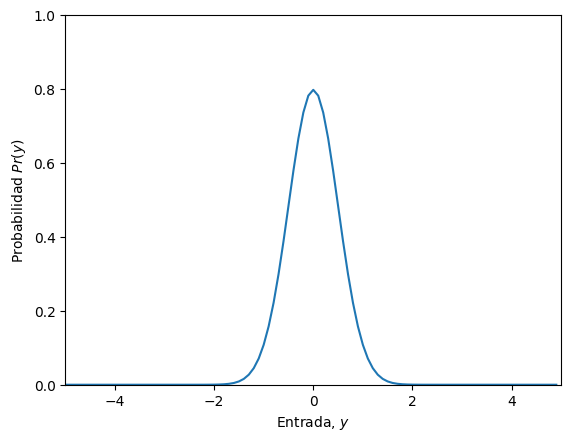

In [53]:
mu = 0; sigma = 0.5
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel(r'Entrada, $y$'); ax.set_ylabel(r'Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

Ahora calculemos la likelihood mediante esta función.

In [54]:
# Devuelve la likelihood de todos los datos bajo el modelo
def compute_likelihood(y_train, mu, sigma):
  # TODO: calcula la likelihood de los datos: el producto de las probabilidades normales de cada dato
  # Primera línea de la ecuación 5.3 de las notas
  # Necesitarás np.prod() y la función normal_distribution utilizada anteriormente
  # Reemplaza la siguiente línea
  likelihood = np.prod(normal_distribution(y_train, mu, sigma))

  return likelihood

En esta sección se implementó la función compute_likelihood, la cual calcula la verosimilitud (Likelihood) de un conjunto de datos bajo una distribución normal. De acuerdo con la primera línea de la ecuación 5.3, la likelihood se obtiene multiplicando las probabilidades individuales de cada observación. Para ello, primero se calcula la probabilidad de cada dato mediante la función normal_distribution y posteriormente se utiliza np.prod para obtener el producto de todas ellas.

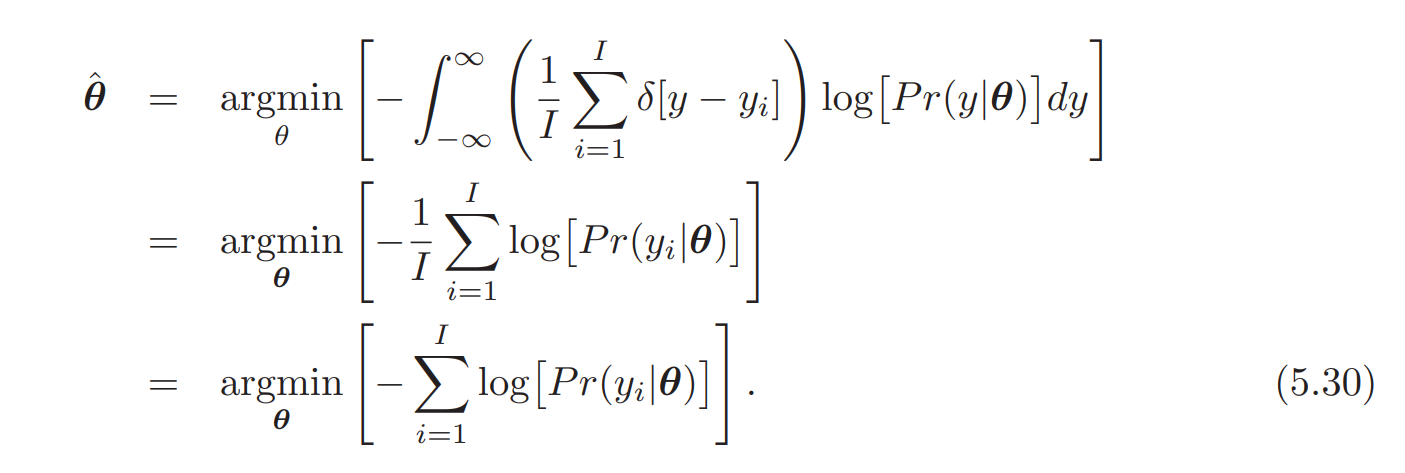

In [55]:
# Prueba la función con un modelo homoscedástico (sigma constante)
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir la media de la distribución gaussiana
mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Establece una desviación estándar razonable
sigma = 0.2
# Calcula la likelihood
likelihood = compute_likelihood(y_train, mu_pred, sigma)
# Verifica que obtengamos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(0.000010624,likelihood))

Respuesta correcta = 0.000010624, Tu respuesta = 0.000010624


Puedes observar que el resultado es muy pequeño, incluso para este pequeño conjunto de datos unidimensional y con un modelo que se ajusta bastante bien. Esto se debe a que es el producto de varias probabilidades que también son pequeñas.
Con conjuntos de datos reales esto se vuelve problemático rápidamente: la likelihood será tan pequeña que no podremos representarla con aritmética normal de precisión finita.

Por esta razón utilizamos la log-likelihood negativa.

In [56]:
# Devuelve la log-likelihood negativa de los datos bajo el modelo
def compute_negative_log_likelihood(y_train, mu, sigma):
  # TODO: calcula la log-likelihood negativa de los datos sin utilizar un producto
  # En otras palabras, calcula menos uno por la suma de los logaritmos de las probabilidades
  # Ecuación 5.4 de las notas
  # Necesitarás np.sum() y np.log()
  # Reemplaza la siguiente línea
  nll = -np.sum(np.log(normal_distribution(y_train, mu, sigma)))

  return nll

En esta sección se implementó la función compute_negative_log_likelihood, la cual calcula la log-likelihood negativa (NLL) del conjunto de datos. En lugar de multiplicar todas las probabilidades, como se hace en la likelihood, se aplica el logaritmo natural a cada probabilidad y posteriormente se suman los resultados. Finalmente, el valor obtenido se multiplica por -1, tal como lo establece la ecuación 5.4. Este procedimiento mejora la estabilidad numérica y facilita el proceso de optimización durante el entrenamiento del modelo.

In [57]:
# Prueba la función con un modelo homoscedástico (sigma constante)
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir la media de la distribución gaussiana
mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Establece una desviación estándar razonable
sigma = 0.2
# Calcula la log-likelihood negativa
nll = compute_negative_log_likelihood(y_train, mu_pred, sigma)
# Verifica que obtengamos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(11.452419564,nll))

Respuesta correcta = 11.452419564, Tu respuesta = 11.452419564


Para completar el análisis, calculemos también la suma de cuadrados.

In [62]:
# Devuelve la distancia cuadrática entre los datos observados (y_train) y la predicción del modelo (y_pred)
def compute_sum_of_squares(y_train, y_pred):
  # TODO: calcula la suma de las distancias cuadráticas entre los datos de entrenamiento y la predicción del modelo
  # Ecuación 5.10 de las notas. Asegúrate de comprenderla y pregunta si tienes dudas
  # Reemplaza la siguiente línea

  sum_of_squares = np.sum((y_train - y_pred)**2)

  return sum_of_squares

En esta sección se implementó la función compute_sum_of_squares, la cual calcula la suma de los errores cuadráticos entre los valores observados y las predicciones generadas por el modelo. De acuerdo con la ecuación 5.10, primero se calcula la diferencia entre cada dato real y su predicción correspondiente, posteriormente cada diferencia se eleva al cuadrado y, finalmente, todas las cantidades se suman para obtener el error total del modelo.

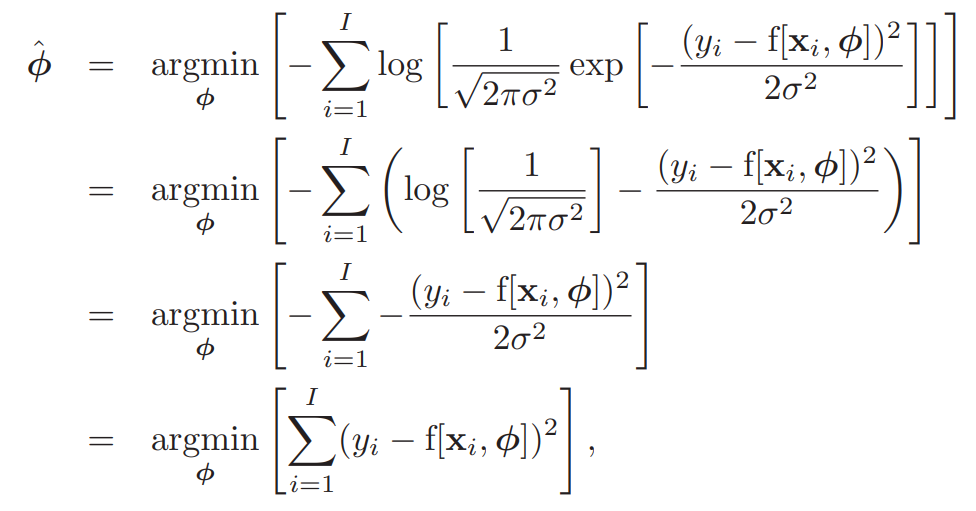

In [63]:
# Prueba nuevamente la función
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir la media de la distribución gaussiana, nuestra mejor predicción de y
y_pred = mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Calcula la suma de cuadrados
sum_of_squares = compute_sum_of_squares(y_train, y_pred)
# Verifica que obtengamos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(2.020992572,sum_of_squares))

Respuesta correcta = 2.020992572, Tu respuesta = 2.020992572


Ahora estudiaremos cómo encontrar la solución de máxima likelihood, mínima log-likelihood negativa y mínimos cuadrados. Para simplificar, supondremos que todos los parámetros son correctos excepto uno y observaremos cómo cambian las tres medidas al modificarlo. Comenzaremos con el desplazamiento general de $y$, `beta_1` (anteriormente `phi_0`).

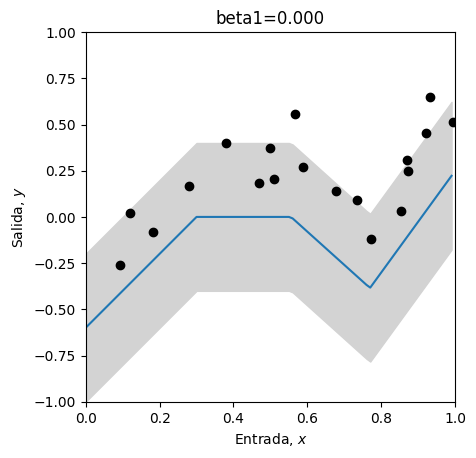

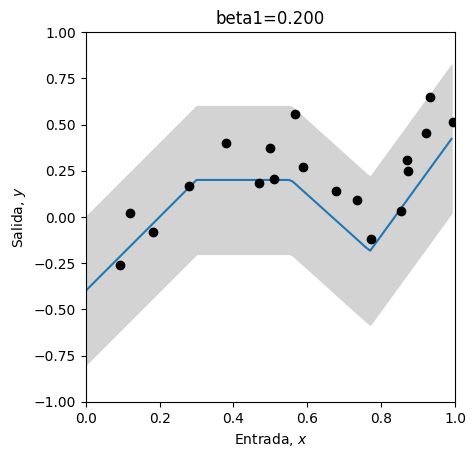

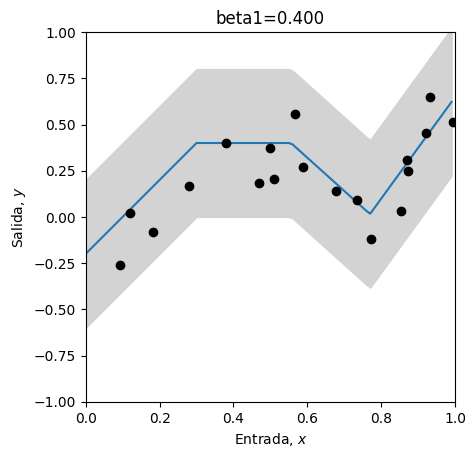

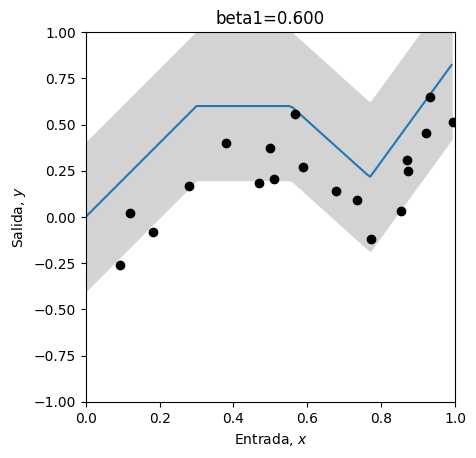

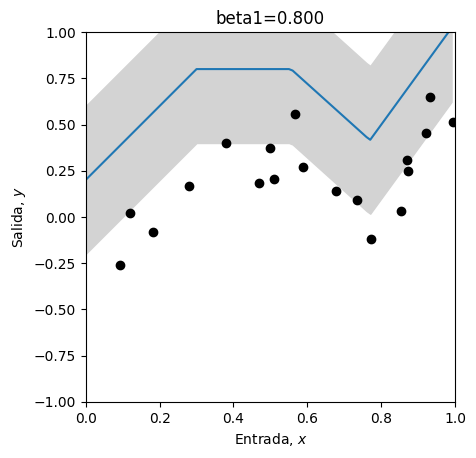

In [64]:
# Define un intervalo de valores para el parámetro
beta_1_vals = np.arange(0,1.0,0.01)
# Crea arreglos para almacenar las likelihoodes, las log-likelihoodes negativas y las sumas de cuadrados
likelihoods = np.zeros_like(beta_1_vals)
nlls = np.zeros_like(beta_1_vals)
sum_squares = np.zeros_like(beta_1_vals)

# Inicializa los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
sigma = 0.2
for count in range(len(beta_1_vals)):
  # Establece el valor del parámetro
  beta_1[0,0] = beta_1_vals[count]
  # Ejecuta la red con los nuevos parámetros
  mu_pred = y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  # Calcula y almacena los tres valores
  likelihoods[count] = compute_likelihood(y_train, mu_pred, sigma)
  nlls[count] = compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count] = compute_sum_of_squares(y_train, y_pred)
  # Dibuja el modelo cada 20 configuraciones del parámetro
  if count % 20 == 0:
    # Ejecuta el modelo para obtener los valores y graficarlos
    y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))


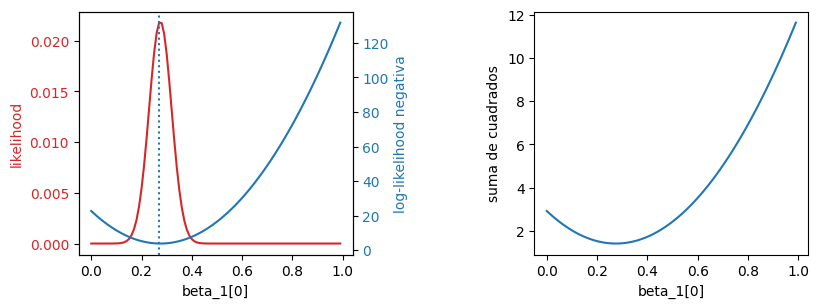

In [65]:
# Grafica la likelihood, la log-likelihood negativa y los mínimos cuadrados según el desplazamiento beta1
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10.5, 5.5)
fig.tight_layout(pad=10.0)
likelihood_color = 'tab:red'
nll_color = 'tab:blue'

ax[0].set_xlabel('beta_1[0]')
ax[0].set_ylabel('likelihood', color = likelihood_color)
ax[0].plot(beta_1_vals, likelihoods, color = likelihood_color)
ax[0].tick_params(axis='y', labelcolor=likelihood_color)

ax00 = ax[0].twinx()
ax00.plot(beta_1_vals, nlls, color = nll_color)
ax00.set_ylabel('log-likelihood negativa', color = nll_color)
ax00.tick_params(axis='y', labelcolor = nll_color)

plt.axvline(x = beta_1_vals[np.argmax(likelihoods)], linestyle='dotted')

ax[1].plot(beta_1_vals, sum_squares); ax[1].set_xlabel('beta_1[0]'); ax[1].set_ylabel('suma de cuadrados')
plt.show()

En esta sección se analiza cómo cambian la Likelihood, la Negative Log-Likelihood y la Suma de los Cuadrados de los Errores al variar el parámetro β₁ del modelo. Se observa que la Likelihood alcanza su valor máximo cuando el modelo ajusta mejor los datos, mientras que la Negative Log-Likelihood y la Suma de Cuadrados alcanzan su mínimo en el mismo punto. Esto confirma experimentalmente la equivalencia teórica entre ambas funciones de pérdida derivada en la ecuación 5.10.

Máxima likelihood = 0.022, en beta_1=0.270
Mínima log-likelihood negativa = 3.826, en beta_1=0.270
Mínimos cuadrados = 1.411, en beta_1=0.270


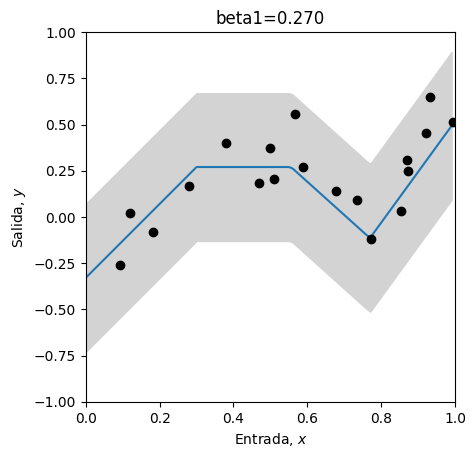

In [66]:
# El máximo de la función de likelihood debe estar en la misma posición que el mínimo de la log-likelihood negativa
# y la solución de mínimos cuadrados
# Comprobémoslo:
print("Máxima likelihood = %3.3f, en beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],beta_1_vals[np.argmax(likelihoods)])))
print("Mínima log-likelihood negativa = %3.3f, en beta_1=%3.3f"%( (nlls[np.argmin(nlls)],beta_1_vals[np.argmin(nlls)])))
print("Mínimos cuadrados = %3.3f, en beta_1=%3.3f"%( (sum_squares[np.argmin(sum_squares)],beta_1_vals[np.argmin(sum_squares)])))

# Grafica el mejor modelo
beta_1[0,0] = beta_1_vals[np.argmin(sum_squares)]
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))

En esta sección se verifica experimentalmente que el máximo de la función de Likelihood coincide con el mínimo de la Negative Log-Likelihood y con el mínimo de la función de suma de cuadrados. Al evaluar el modelo para distintos valores del parámetro β₁, se observa que los tres criterios alcanzan su punto óptimo en el mismo valor (β₁ ≈ 0.270). Este resultado confirma la derivación teórica mostrada en la ecuación 5.10, donde se demuestra que minimizar la Negative Log-Likelihood de una distribución normal con varianza constante es equivalente a minimizar la suma de los errores cuadráticos.

Las tres medidas producen la misma respuesta. Sin embargo, las gráficas anteriores muestran que la likelihood es muy pequeña salvo cuando los parámetros son casi correctos. Por ello, en la práctica se utiliza la log-likelihood negativa o los mínimos cuadrados.<br>

Hagamos ahora lo mismo con el parámetro de desviación estándar de la red. No es una salida de la red, salvo que decidamos modelarlo así, pero afecta la likelihood.



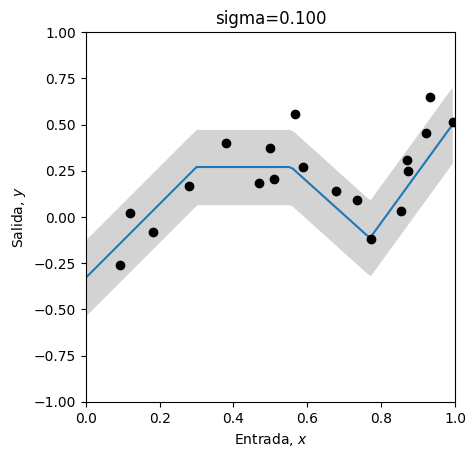

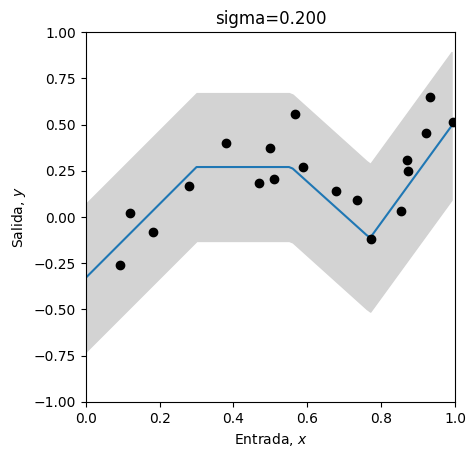

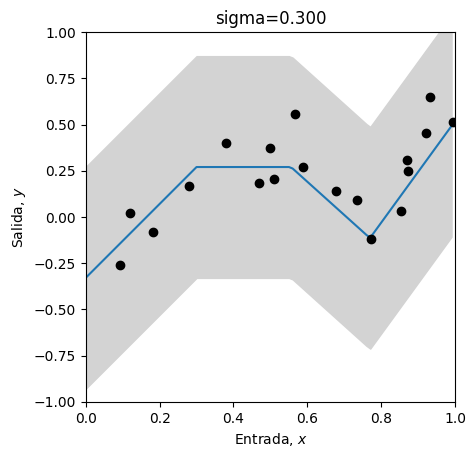

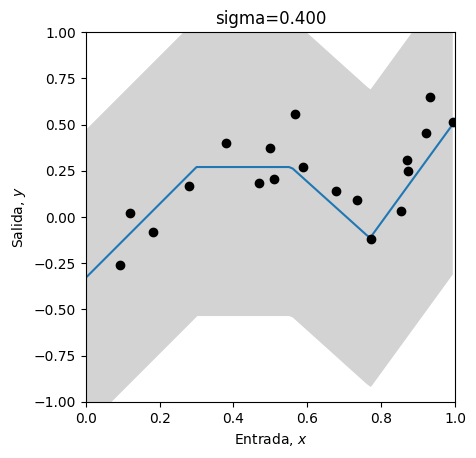

In [70]:
# Define un intervalo de valores para el parámetro
sigma_vals = np.arange(0.1,0.5,0.005)
# Crea arreglos para almacenar las likelihoodes, las log-likelihoodes negativas y las sumas de cuadrados
likelihoods = np.zeros_like(sigma_vals)
nlls = np.zeros_like(sigma_vals)
sum_squares = np.zeros_like(sigma_vals)

# Inicializa los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Utiliza el mejor desplazamiento encontrado
beta_1[0,0] = 0.27
for count in range(len(sigma_vals)):
  # Establece el valor del parámetro
  sigma = sigma_vals[count]
  # Ejecuta la red con los nuevos parámetros
  mu_pred = y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  # Calcula y almacena los tres valores
  likelihoods[count] = compute_likelihood(y_train, mu_pred, sigma)
  nlls[count] = compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count] = compute_sum_of_squares(y_train, y_pred)
  # Dibuja el modelo cada 20 configuraciones del parámetro
  if count % 20 == 0:
    # Ejecuta el modelo para obtener los valores y graficarlos
    y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model=sigma, title="sigma=%3.3f"%(sigma))

En esta sección se estudia el efecto del parámetro σ (desviación estándar) sobre la Likelihood, la Negative Log-Likelihood y la Suma de los Cuadrados de los Errores, manteniendo fijo el mejor valor de β₁ encontrado previamente. Se observa cómo la variabilidad del modelo influye en la forma de la distribución y en la evaluación del ajuste. Este análisis permite entender el papel de σ como medida de incertidumbre en el modelo probabilístico.

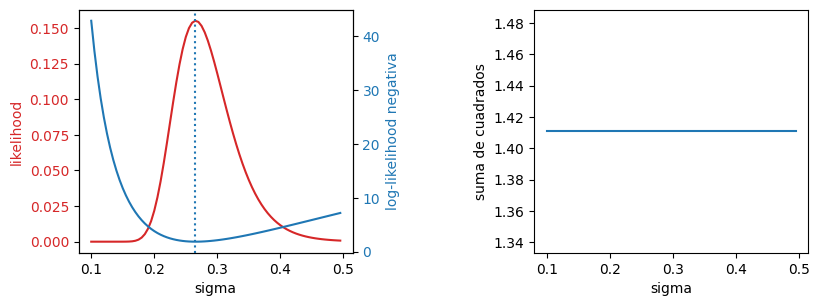

In [68]:
# Grafica la likelihood, la log-likelihood negativa y los mínimos cuadrados según la desviación estándar sigma
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10.5, 5.5)
fig.tight_layout(pad=10.0)
likelihood_color = 'tab:red'
nll_color = 'tab:blue'


ax[0].set_xlabel('sigma')
ax[0].set_ylabel('likelihood', color = likelihood_color)
ax[0].plot(sigma_vals, likelihoods, color = likelihood_color)
ax[0].tick_params(axis='y', labelcolor=likelihood_color)

ax00 = ax[0].twinx()
ax00.plot(sigma_vals, nlls, color = nll_color)
ax00.set_ylabel('log-likelihood negativa', color = nll_color)
ax00.tick_params(axis='y', labelcolor = nll_color)

plt.axvline(x = sigma_vals[np.argmax(likelihoods)], linestyle='dotted')

ax[1].plot(sigma_vals, sum_squares); ax[1].set_xlabel('sigma'); ax[1].set_ylabel('suma de cuadrados')
plt.show()

En esta sección se grafica el comportamiento de la Likelihood, la Negative Log-Likelihood y la Suma de los Cuadrados de los Errores al variar el parámetro σ, manteniendo fijo el mejor valor de β₁. Se observa que la Likelihood alcanza su valor máximo en un punto específico de σ, mientras que la Negative Log-Likelihood y la Suma de Cuadrados alcanzan su mínimo en el mismo valor. Este resultado confirma que el parámetro σ controla la dispersión del modelo y afecta directamente la evaluación probabilística del ajuste, sin alterar la equivalencia entre las funciones de costo.

Máxima likelihood = 0.155, en sigma=0.265
Mínima log-likelihood negativa = 1.864, en sigma=0.265


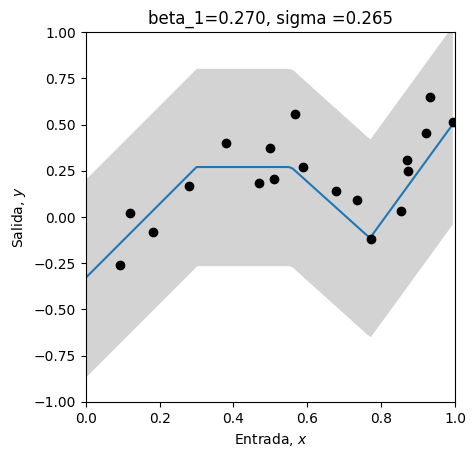

In [69]:
# El máximo de la función de likelihood debe estar en la misma posición que el mínimo de la log-likelihood negativa
# La solución de mínimos cuadrados no depende de sigma, por lo que es constante y no resulta útil aquí.
# Comprobémoslo:
print("Máxima likelihood = %3.3f, en sigma=%3.3f"%( (likelihoods[np.argmax(likelihoods)],sigma_vals[np.argmax(likelihoods)])))
print("Mínima log-likelihood negativa = %3.3f, en sigma=%3.3f"%( (nlls[np.argmin(nlls)],sigma_vals[np.argmin(nlls)])))
# Grafica el mejor modelo
sigma= sigma_vals[np.argmin(nlls)]
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta_1=%3.3f, sigma =%3.3f"%(beta_1[0,0],sigma))

En esta sección se verifica que el máximo de la función de Likelihood coincide con el mínimo de la Negative Log-Likelihood al variar el parámetro σ. Los resultados obtenidos muestran que ambas funciones alcanzan su punto óptimo en σ ≈ 0.265. Este comportamiento confirma nuevamente la equivalencia entre ambas funciones de costo, ya que optimizar una implica optimizar la otra. Además, se observa que la solución de mínimos cuadrados no depende de σ, ya que este parámetro solo afecta la escala de la distribución probabilística, pero no la estructura del error cuadrático.

Para ajustar el modelo neuronal completo, variaríamos los 10 parámetros de la red contenidos en $\boldsymbol\beta_{0},\boldsymbol\Omega_{0},\boldsymbol\beta_{1},\boldsymbol\Omega_{1}$, y posiblemente $\sigma$, hasta encontrar la combinación con máxima likelihood, mínima log-likelihood negativa o mínimos cuadrados.<br><br>

Aquí solo variamos un parámetro a la vez para observar con mayor claridad lo que sucede. Este método se conoce como **descenso por coordenadas**.
